In [1]:
import re
from pathlib import Path

import pandas as pd
from matplotlib import pyplot as plt

In [2]:
plt.style.use("../clane.v2.mplstyle")
PLOTW = 3.25  # 6.75 two column width, 0.25 pad
plt.rcParams["figure.dpi"] = 300

In [3]:
SPACE_NAMES = {
    "schaefer400": "parcel",
    "flat": "flat",
    "mni_cortex": "volume",
}

SPACE_LRS = {
    "schaefer400": 3e-4,
    "flat": 1e-3,
    "mni_cortex": 1e-3,
}

In [4]:
# get paths for comparison models
comparison_dir = Path("/data/connor/fmri-fm-eval/experiments/260223")
paths = sorted(
    p
    for p in (comparison_dir / "output/eval_logistic").rglob("eval_table.csv")
    if "flat_mae" not in p.parts[-2]
)
print(len(paths))

tables = []
for path in paths:
    table = pd.read_csv(path)
    table.insert(0, "run", 1)
    tables.append(table)

# paths for cortex mae
paths = sorted(
    Path("../input_space_v2/output/input_space_v2").rglob("*/eval_v2/*_logistic/eval_table.csv")
)
print(len(paths))

for path in paths:
    table = pd.read_csv(path)
    key = path.parts[-4]
    match = re.search(r"(schaefer400|mni_cortex|flat)_lr([-0-9e]+)_([0-9])", key)
    space, lr, run = match.groups()
    table.insert(0, "run", int(run))
    tables.append(table)

trait_table = pd.concat(tables, ignore_index=True)
print(trait_table.shape)
trait_table.head()

56
272
(66256, 14)


,run,model,repr,clf,dataset,trial,C,split,acc,acc_std,f1,f1_std,bacc,bacc_std
0,1,brain_harmonix_f,patch,logistic,aabc_age,NaN,0.359381,train,0.903543,0.013435,0.903674,0.013445,0.902960,0.013532
1,1,brain_harmonix_f,patch,logistic,aabc_age,NaN,0.359381,test,0.307692,0.066559,0.312500,0.066077,0.305632,0.066398
2,1,brain_harmonix_f,patch,logistic,aabc_age,1.0,0.000774,train,0.517717,0.021086,0.509516,0.021577,0.518099,0.021128
3,1,brain_harmonix_f,patch,logistic,aabc_age,1.0,0.000774,test,0.346154,0.061052,0.336078,0.060248,0.345238,0.060946
4,1,brain_harmonix_f,patch,logistic,aabc_age,2.0,0.046416,train,0.696850,0.020321,0.696624,0.020425,0.697375,0.020326


In [5]:
trait_metric = "bacc"

trait_summary = trait_table.query("split == 'test' and trial > 0").pivot_table(
    values=[trait_metric],
    index=["model", "run", "repr"],
    columns="dataset",
    aggfunc=["mean", "std"],
)
trait_summary.loc[(slice(None), 1), :]

mean                                 \
                                      bacc                                  
dataset                           aabc_age  aabc_sex  abide_dx adhd200_dx   
model                  run repr                                             
brain_harmonix_f       1   patch  0.370064  0.583791  0.504401   0.599117   
brain_jepa_vitb_ep300  1   patch  0.279567  0.492935  0.526455   0.590980   
brain_semantoks        1   cls    0.463723  0.804203  0.568209   0.552514   
                           patch  0.470755  0.790270  0.565909   0.589170   
brainlm_vitmae_111m    1   patch  0.437605  0.648539  0.484601   0.601829   
connectome_schaefer400 1   cls    0.455730  0.818750  0.598146   0.570043   
flat_mae               1   cls    0.417827  0.882833  0.591549   0.602592   
                           patch  0.424799  0.866739  0.604554   0.581935   
mni_cortex_mae         1   patch  0.526593  0.851324  0.592080   0.587703   
neurostorm             1   patch  0.565755  0.826900  0.535494   0.611081   
schaefer400_mae        1   cls    0.433306  0.700428  0.603514   0.578620   
                           patch  0.437287  0.712942  0.628477   0.575705   
swift                  1   patch  0.381058  0.744816  0.536817   0.592283   

                                                                               \
                                                                                
dataset                          adni_ad_vs_cn hcpya_rest1lr_gender   ppmi_dx   
model                  run repr                                                 
brain_harmonix_f       1   patch      0.516000             0.792115  0.563145   
brain_jepa_vitb_ep300  1   patch      0.620516             0.813750  0.568391   
brain_semantoks        1   cls        0.595565             0.792692  0.554372   
                           patch      0.566242             0.759231  0.561863   
brainlm_vitmae_111m    1   patch      0.555371             0.822019  0.526944   
connectome_schaefer400 1   cls        0.586274             0.787885  0.580187   
flat_mae               1   cls        0.629355             0.876058  0.587368   
                           patch      0.653000             0.869808  0.593918   
mni_cortex_mae         1   patch      0.640323                  NaN  0.573094   
neurostorm             1   patch      0.667661             0.886346  0.534028   
schaefer400_mae        1   cls        0.616419             0.805481  0.598722   
                           patch      0.632774             0.813750  0.616570   
swift                  1   patch      0.607339             0.829231  0.557827   

                                       std                                 \
                                      bacc                                  
dataset                           aabc_age  aabc_sex  abide_dx adhd200_dx   
model                  run repr                                             
brain_harmonix_f       1   patch  0.060749  0.064717  0.035288   0.056726   
brain_jepa_vitb_ep300  1   patch  0.058065  0.050441  0.040792   0.055406   
brain_semantoks        1   cls    0.062970  0.055920  0.041024   0.057557   
                           patch  0.059849  0.050585  0.039254   0.052887   
brainlm_vitmae_111m    1   patch  0.069483  0.066373  0.029798   0.056923   
connectome_schaefer400 1   cls    0.057445  0.054945  0.039157   0.057048   
flat_mae               1   cls    0.066008  0.046982  0.039810   0.056743   
                           patch  0.062501  0.044123  0.043021   0.053675   
mni_cortex_mae         1   patch  0.055947  0.052709  0.043897   0.064979   
neurostorm             1   patch  0.065507  0.051828  0.045721   0.056529   
schaefer400_mae        1   cls    0.066854  0.060258  0.043182   0.061302   
                           patch  0.065896  0.052743  0.045607   0.061695   
swift                  1   patch  0.062586  0.065910  0.042036   0.055728   

                                        

In [6]:
paths = sorted(
    p
    for p in (comparison_dir / "output/eval_probe").rglob("eval_table.csv")
    if "flat_mae" not in p.parts[-2]
)
print(len(paths))

tables = []
for path in paths:
    # hack: use version with coordinate wise normalization if it exists
    norm_path = Path(str(path).replace("260223", "coord_normalize"))
    if norm_path.exists():
        print(f"replacing {path} -> {norm_path}")
        path = norm_path
    table = pd.read_csv(path)
    table.insert(0, "run", 1)
    tables.append(table)

paths = sorted(
    Path("../input_space_v2/output/input_space_v2").rglob("*/eval_v2/*_attn/eval_table.csv")
)
print(len(paths))

for path in paths:
    table = pd.read_csv(path)
    key = path.parts[-4]
    match = re.search(r"(schaefer400|mni_cortex|flat)_lr([-0-9e]+)_([0-9])", key)
    space, lr, run = match.groups()
    table.insert(0, "run", int(run))
    tables.append(table)

state_table = pd.concat(tables, ignore_index=True)
print(state_table.shape)
state_table.head()

26
replacing /data/connor/fmri-fm-eval/experiments/260223/output/eval_probe/hcpya_task21__brain_harmonix_f__patch__attn/eval_table.csv -> /data/connor/fmri-fm-eval/experiments/coord_normalize/output/eval_probe/hcpya_task21__brain_harmonix_f__patch__attn/eval_table.csv
replacing /data/connor/fmri-fm-eval/experiments/260223/output/eval_probe/hcpya_task21__brain_jepa_vitb_ep300__patch__attn/eval_table.csv -> /data/connor/fmri-fm-eval/experiments/coord_normalize/output/eval_probe/hcpya_task21__brain_jepa_vitb_ep300__patch__attn/eval_table.csv
replacing /data/connor/fmri-fm-eval/experiments/260223/output/eval_probe/hcpya_task21__brainlm_vitmae_111m__patch__attn/eval_table.csv -> /data/connor/fmri-fm-eval/experiments/coord_normalize/output/eval_probe/hcpya_task21__brainlm_vitmae_111m__patch__attn/eval_table.csv
replacing /data/connor/fmri-fm-eval/experiments/260223/output/eval_probe/hcpya_task21__neurostorm__patch__attn/eval_table.csv -> /data/connor/fmri-fm-eval/experiments/coord_normalize/

,run,model,repr,clf,dataset,ckpt,epoch,lr,wd,hparam_id,hparam,split,loss,acc,acc_std,f1,f1_std
0,1,brain_harmonix_f,patch,attn,hcpya_task21,best,19,0.0066,0.05,43,"[22, 1.0]",train,0.056337,0.986789,0.000832,0.986089,0.000953
1,1,brain_harmonix_f,patch,attn,hcpya_task21,best,19,0.0066,0.05,43,"[22, 1.0]",validation,0.175493,0.949653,0.003368,0.941685,0.004346
2,1,brain_harmonix_f,patch,attn,hcpya_task21,best,19,0.0066,0.05,43,"[22, 1.0]",test,0.195906,0.943651,0.003352,0.931137,0.004337
3,1,brain_harmonix_f,patch,linear,hcpya_task21,best,15,0.0150,0.05,48,"[50, 1.0]",train,2.713324,0.192958,0.001585,0.052692,0.001397
4,1,brain_harmonix_f,patch,linear,hcpya_task21,best,15,0.0150,0.05,48,"[50, 1.0]",validation,2.728768,0.190724,0.003340,0.052419,0.003110


In [7]:
state_summary = state_table.query("split == 'test'").pivot_table(
    values=["acc", "acc_std"], index=["model", "run", "repr", "clf"], columns="dataset"
)
state_summary.loc[(slice(None), 1), :]

acc               \
dataset                                 hcpya_task21 nsd_cococlip   
model                  run repr  clf                                
brain_harmonix_f       1   patch attn       0.943651     0.238033   
                                 linear     0.181746     0.064007   
brain_jepa_vitb_ep300  1   patch attn       0.735516          NaN   
                                 linear     0.171429          NaN   
brain_semantoks        1   cls   linear     0.689087     0.084045   
                           patch attn       0.896429     0.157885   
                                 linear     0.813095     0.110204   
brainlm_vitmae_111m    1   patch attn       0.925000          NaN   
                                 linear     0.161706          NaN   
connectome_schaefer400 1   cls   linear     0.824405     0.074397   
flat_mae               1   patch attn       0.986905     0.304267   
identity_schaefer400   1   patch mlp        0.942857     0.133210   
mni_cortex_mae         1   patch attn       0.959127     0.256401   
neurostorm             1   patch attn       0.704762     0.122078   
                                 linear     0.173413     0.063636   
schaefer400_mae        1   patch attn       0.975992     0.274954   
swift                  1   patch attn       0.635714     0.077365   
                                 linear     0.170040     0.066976   

                                             acc_std                
dataset                                 hcpya_task21  nsd_cococlip  
model                  run repr  clf                                
brain_harmonix_f       1   patch attn       0.003352  4.752447e-03  
                                 linear     0.003322  1.387779e-17  
brain_jepa_vitb_ep300  1   patch attn       0.005929           NaN  
                                 linear     0.000392           NaN  
brain_semantoks        1   cls   linear     0.005937  3.276170e-03  
                           patch attn       0.004210  4.085324e-03  
                                 linear     0.005294  3.586247e-03  
brainlm_vitmae_111m    1   patch attn       0.003698           NaN  
                                 linear     0.001890           NaN  
connectome_schaefer400 1   cls   linear     0.005130  3.272901e-03  
flat_mae               1   patch attn       0.001479  5.561198e-03  
identity_schaefer400   1   patch mlp        0.003208  4.264024e-03  
mni_cortex_mae         1   patch attn       0.002758  5.283591e-03  
neurostorm             1   patch attn       0.005748  3.718283e-03  
                                 linear     0.001199  1.387779e-17  
schaefer400_mae        1   patch attn       0.002195  5.143585e-03  
swift                  1   patch attn       0.005744  3.167855e-03  
                                 linear     0.000723  1.918293e-03

In [8]:
MODEL_NAMES = {
    "connectome_schaefer400": "Connectome",
    "identity_schaefer400": "MLP",
    "swift": "SwiFT",
    "brainlm_vitmae_111m": "BrainLM",
    "brain_jepa_vitb_ep300": "Brain-JEPA",
    "brain_harmonix_f": "BrainHarmonix-F",
    "neurostorm": "NeuroSTORM",
    "brain_semantoks": "Brain-Semantoks",
    "flat_mae": "CortexMAE",
    "schaefer400_mae": "CortexMAE-P",
    "mni_cortex_mae": "CortexMAE-V",
}

# MODEL_COLORS = {model: plt.cm.tab10.colors[ii] for ii, model in enumerate(MODEL_NAMES)}
colors = [
    "#0072B2",
    "#009E73",
    "#F0E442",
    "#E69F00",
    "#D55E00",
    "#CC79A7",
    "#845B97",
    "#845B97",
    "#845B97",
]
MODEL_COLORS = {model: colors[ii] for ii, model in enumerate(list(MODEL_NAMES)[2:])}

gray_color = "#474747"

MODEL_MARKERS = {
    "flat_mae": "^",
    "mni_cortex_mae": "s",
    "swift": "s",
    "neurostorm": "s",
}

DATASET_NAMES = {
    "abide_dx": "ABIDE Dx",
    "abide_age": "ABIDE Age",
    "abide_sex": "ABIDE Sex",
    "adhd200_dx": "ADHD200 Dx",
    "adhd200_sex": "ADHD200 Sex",
    "adni_ad_vs_cn": "ADNI Dx",
    "adni_sex": "ADNI Sex",
    "ppmi_dx": "PPMI Dx",
    "ppmi_sex": "PPMI Sex",
    "ppmi_age": "PPMI Age",
    "hcpya_rest1lr_gender": "HCP-YA Sex",
    "hcpya_rest1lr_age": "HCP-YA Age",
    "hcpya_rest1lr_neofacn": "HCP-YA NEO-N",
    "aabc_sex": "HCP-A Sex",
    "aabc_age": "HCP-A Age",
    "hcpya_task21": "HCP-YA Task21",
    "nsd_cococlip": "NSD COCO24",
}

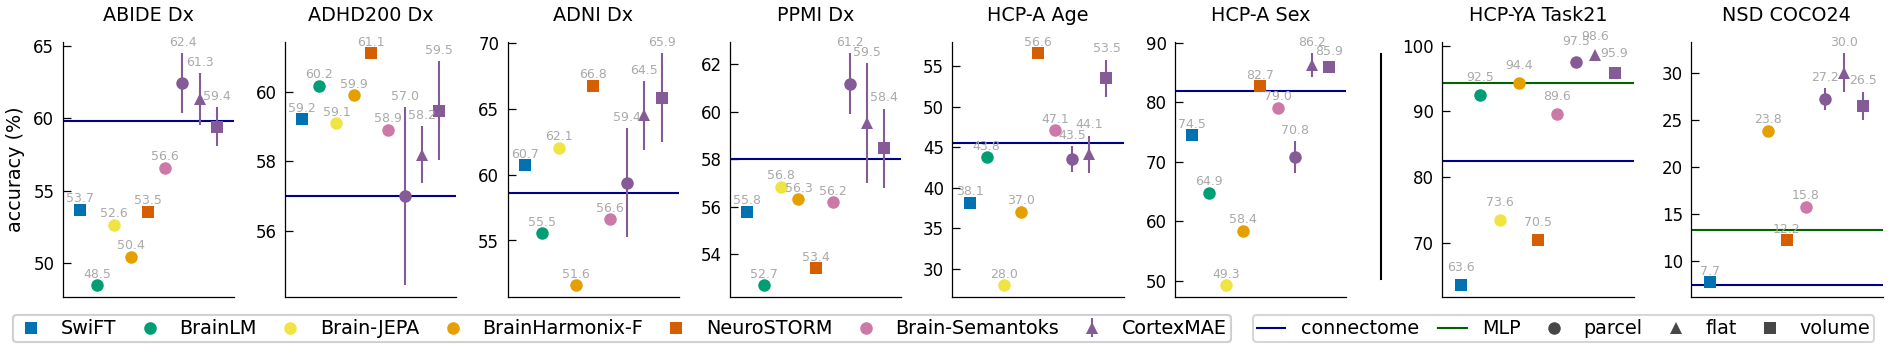

In [11]:
from matplotlib.ticker import FormatStrFormatter


models = [
    "swift",
    "brainlm_vitmae_111m",
    "brain_jepa_vitb_ep300",
    "brain_harmonix_f",
    "neurostorm",
    "brain_semantoks",
    "schaefer400_mae",
    "flat_mae",
    "mni_cortex_mae",
]

trait_datasets = [
    "abide_dx",
    "adhd200_dx",
    "adni_ad_vs_cn",
    "ppmi_dx",
    "aabc_age",
    "aabc_sex",
]
state_datasets = ["hcpya_task21", "nsd_cococlip"]

fig = plt.figure(figsize=(2 * PLOTW + 0.25, 1.0))
subfigs = fig.subfigures(1, 2, wspace=0.0, width_ratios=[len(trait_datasets), len(state_datasets)])

axs_t = subfigs[0].subplots(1, len(trait_datasets))

handle_map = {}

for ii, (ax, ds) in enumerate(zip(axs_t, trait_datasets)):
    vmin = trait_summary.loc[:, ("mean", trait_metric, ds)].min()
    vmax = trait_summary.loc[:, ("mean", trait_metric, ds)].max()

    plt.sca(ax)
    plt.axhline(
        100 * trait_summary.loc[("connectome_schaefer400", 1, "cls"), ("mean", trait_metric, ds)],
        color="darkblue",
        lw=0.5,
    )

    for jj, model in enumerate(models):
        values = trait_summary.loc[(model, slice(None), "patch"), ("mean", trait_metric, ds)]
        acc_pct = 100 * values.mean()
        std_pct = 100 * values.std()
        ci_pct = 2 * std_pct if not pd.isna(std_pct) else 0.0

        color = MODEL_COLORS[model]

        if ci_pct > 0:
            ax.errorbar(
                [jj],
                [acc_pct],
                yerr=[ci_pct],
                fmt=MODEL_MARKERS.get(model, "o"),
                color=color,
                elinewidth=0.5,
                ms=3,
                mew=0,
            )
        else:
            ax.plot(
                [jj],
                [acc_pct],
                MODEL_MARKERS.get(model, "o"),
                color=color,
                ms=3,
                mew=0,
            )[0]

        ax.text(
            jj,
            acc_pct + ci_pct + 2 * (vmax - vmin),
            f"{acc_pct:.1f}",
            fontsize=3.0,
            color="darkgray",
            ha="center",
            va="bottom",
        )

        # if model == "flat_mae":
        #     ax.axhspan(acc_pct - ci_pct, acc_pct + ci_pct, color=color, alpha=0.2)

    ax.set_title(DATASET_NAMES.get(ds, ds), fontsize="small", pad=5)
    ax.set_xticks([])  # hide x ticks since we have legend
    if ii == 0:
        ax.set_ylabel("accuracy (%)", fontsize="small")
    # ax.grid(True, alpha=0.3, axis='y')
    ax.yaxis.set_major_formatter(FormatStrFormatter("%.0f"))
    ax.set_xlim(-1, len(models))
    ax.tick_params(axis="both", which="major", labelsize=4)

axs_s = subfigs[1].subplots(1, len(state_datasets))

for ii, (ax, ds) in enumerate(zip(axs_s, state_datasets)):
    vmin = state_summary.loc[:, ("acc", ds)].min()
    vmax = state_summary.loc[:, ("acc", ds)].max()

    plt.sca(ax)
    handle_map["connectome"] = plt.axhline(
        100 * state_summary.loc[("connectome_schaefer400", 1, "cls", "linear"), ("acc", ds)],
        color="darkblue",
        lw=0.5,
    )
    handle_map["mlp"] = plt.axhline(
        100 * state_summary.loc[("identity_schaefer400", 1, "patch", "mlp"), ("acc", ds)],
        color="darkgreen",
        lw=0.5,
    )

    for jj, model in enumerate(models):
        values = state_summary.loc[(model, slice(None), "patch", "attn"), ("acc", ds)]
        acc_pct = 100 * values.mean()
        std_pct = 100 * values.std()
        ci_pct = 2 * std_pct if not pd.isna(std_pct) else 0.0

        color = MODEL_COLORS[model]

        if ci_pct > 0:
            handle_map[model] = ax.errorbar(
                [jj],
                [acc_pct],
                yerr=[ci_pct],
                fmt=MODEL_MARKERS.get(model, "o"),
                color=color,
                elinewidth=0.5,
                ms=3,
                mew=0,
            )
        else:
            handle_map[model] = ax.plot(
                [jj],
                [acc_pct],
                MODEL_MARKERS.get(model, "o"),
                color=color,
                ms=3,
                mew=0,
            )[0]

        ax.text(
            jj,
            acc_pct + ci_pct + 2 * (vmax - vmin),
            f"{acc_pct:.1f}",
            fontsize=3.0,
            color="darkgray",
            ha="center",
            va="bottom",
        )

        # if model == "flat_mae":
        #     ax.axhspan(acc_pct - ci_pct, acc_pct + ci_pct, color=color, alpha=0.2)

    ax.set_title(DATASET_NAMES.get(ds, ds), fontsize="small", pad=5)
    ax.set_xticks([])  # hide x ticks since we have legend
    ax.yaxis.set_major_formatter(FormatStrFormatter("%.0f"))
    ax.set_xlim(-1, len(models))
    ax.tick_params(axis="both", which="major", labelsize=4)


handle_map["parcel"] = ax.plot([], [], "o", color=gray_color, ms=3, mew=0)[0]
handle_map["volume"] = ax.plot([], [], "s", color=gray_color, ms=3, mew=0)[0]
handle_map["flat"] = ax.plot([], [], "^", color=gray_color, ms=3, mew=0)[0]

subfigs[0].subplots_adjust(wspace=0.3, bottom=0.03, right=0.97)
subfigs[1].subplots_adjust(wspace=0.3, bottom=0.03, left=0.1)

x = 0.745
ymin, ymax = 0.09, 0.84
line = plt.Line2D((x, x), (ymin, ymax), color="k", linewidth=0.5)
fig.add_artist(line)

# Legend 1: models
exclude = {"schaefer400_mae", "mni_cortex_mae"}
model_labels = [MODEL_NAMES[model] for model in models if model not in exclude]
model_handles = [handle_map[model] for model in models if model not in exclude]
leg1 = fig.legend(
    model_handles,
    model_labels,
    loc="upper center",
    bbox_to_anchor=(0.37, 0.0),
    ncol=len(model_labels),
    frameon=True,
)

# Legend 2: baselines + input spaces
other_labels = ["connectome", "MLP", "parcel", "flat", "volume"]
other_handles = [
    handle_map["connectome"],
    handle_map["mlp"],
    handle_map["parcel"],
    handle_map["flat"],
    handle_map["volume"],
]
fig.legend(
    other_handles,
    other_labels,
    loc="upper center",
    bbox_to_anchor=(0.835, 0.0),
    ncol=len(other_labels),
    frameon=True,
)
fig.add_artist(leg1)  # re-add first legend so both are visible
# fig.savefig("results/trait_state_probe.pdf")

In [12]:
def format_acc_std(acc, std):
    """Format accuracy and std as 'XX.XX ± YY.YY'"""
    if pd.isna(acc):
        return "—"
    s = f"{acc * 100:.1f}"
    if not pd.isna(std):
        s = f"{s} ± {std * 100:.1f}"
    return s

In [13]:
records = []

for model in models:
    record = {"model": MODEL_NAMES[model]}
    for ds in trait_datasets:
        acc = trait_summary.loc[(model, slice(None), "patch"), ("mean", trait_metric, ds)].mean()
        std = trait_summary.loc[(model, slice(None), "patch"), ("mean", trait_metric, ds)].std()
        record[DATASET_NAMES.get(ds, ds)] = format_acc_std(acc, std)
    for ds in state_datasets:
        acc = state_summary.loc[(model, slice(None), "patch", "attn"), ("acc", ds)].mean()
        std = state_summary.loc[(model, slice(None), "patch", "attn"), ("acc", ds)].std()
        record[DATASET_NAMES.get(ds, ds)] = format_acc_std(acc, std)
    records.append(record)

result_fmt = pd.DataFrame(records)
print(result_fmt.to_markdown(index=False))

| model           | ABIDE Dx   | ADHD200 Dx   | ADNI Dx    | PPMI Dx    | HCP-A Age   | HCP-A Sex   | HCP-YA Task21   | NSD COCO24   |
|:----------------|:-----------|:-------------|:-----------|:-----------|:------------|:------------|:----------------|:-------------|
| SwiFT           | 53.7       | 59.2         | 60.7       | 55.8       | 38.1        | 74.5        | 63.6            | 7.7          |
| BrainLM         | 48.5       | 60.2         | 55.5       | 52.7       | 43.8        | 64.9        | 92.5            | —            |
| Brain-JEPA      | 52.6       | 59.1         | 62.1       | 56.8       | 28.0        | 49.3        | 73.6            | —            |
| BrainHarmonix-F | 50.4       | 59.9         | 51.6       | 56.3       | 37.0        | 58.4        | 94.4            | 23.8         |
| NeuroSTORM      | 53.5       | 61.1         | 66.8       | 53.4       | 56.6        | 82.7        | 70.5            | 12.2         |
| Brain-Semantoks | 56.6       | 58.9         | 56.6   

In [10]:
# separate table comparing with and without coord norm
paths = sorted(
    p
    for p in (comparison_dir / "output/eval_probe").rglob("eval_table.csv")
    if "flat_mae" not in p.parts[-2]
)
print(len(paths))

tables = []
for path in paths:
    table = pd.read_csv(path)
    table = table.query("split == 'test' and repr == 'patch' and clf == 'attn'").loc[
        :, ["model", "dataset", "acc"]
    ]
    table.insert(0, "coord", False)
    tables.append(table)

    norm_path = Path(str(path).replace("260223", "coord_normalize"))
    if norm_path.exists():
        table = pd.read_csv(norm_path)
        table = table.query("split == 'test' and repr == 'patch' and clf == 'attn'").loc[
            :, ["model", "dataset", "acc"]
        ]
        table.insert(0, "coord", True)
        tables.append(table)

paths = sorted(
    p
    for p in (comparison_dir / "output/eval_logistic").rglob("eval_table.csv")
    if "flat_mae" not in p.parts[-2]
)
print(len(paths))

for path in paths:
    table = pd.read_csv(path)
    table = (
        table.query("trial > 0 and split == 'test' and repr == 'patch' and clf == 'logistic'")
        .loc[:, ["model", "dataset", "bacc"]]
        .groupby(["model", "dataset"])  # average over splits
        .agg({"bacc": "mean"})
        .reset_index()
        .rename(columns={"bacc": "acc"})  # rename bacc -> acc for convenience
    )
    table.insert(0, "coord", False)
    tables.append(table)

    norm_path = Path(str(path).replace("260223", "coord_normalize"))
    if norm_path.exists():
        table = pd.read_csv(norm_path)
        table = (
            table.query("trial > 0 and split == 'test' and repr == 'patch' and clf == 'logistic'")
            .loc[:, ["model", "dataset", "bacc"]]
            .groupby(["model", "dataset"])  # average over splits
            .agg({"bacc": "mean"})
            .reset_index()
            .rename(columns={"bacc": "acc"})  # rename bacc -> acc for convenience
        )
        table.insert(0, "coord", True)
        tables.append(table)

coord_table = pd.concat(tables, ignore_index=True)
print(coord_table.shape)
coord_table.head()

26


56
(90, 4)


,coord,model,dataset,acc
0,False,brain_harmonix_f,hcpya_task21,0.328571
1,True,brain_harmonix_f,hcpya_task21,0.943651
2,False,brain_jepa_vitb_ep300,hcpya_task21,0.168651
3,True,brain_jepa_vitb_ep300,hcpya_task21,0.735516
4,False,brain_semantoks,hcpya_task21,0.896429


In [11]:
coord_summary = coord_table.pivot_table(values="acc", index=["coord", "model"], columns="dataset")
coord_summary

dataset                      aabc_age  aabc_sex  abide_dx  adhd200_dx  \
coord model                                                             
False brain_harmonix_f       0.370064  0.583791  0.504401    0.599117   
      brain_jepa_vitb_ep300  0.279567  0.492935  0.526455    0.590980   
      brain_semantoks        0.470755  0.790270  0.565909    0.589170   
      brainlm_vitmae_111m    0.437605  0.648539  0.484601    0.601829   
      neurostorm             0.565755  0.826900  0.535494    0.611081   
      swift                  0.381058  0.744816  0.536817    0.592283   
True  brain_harmonix_f       0.409258  0.574158  0.528398    0.566689   
      brain_jepa_vitb_ep300  0.275996  0.501583  0.535467    0.504339   
      brainlm_vitmae_111m    0.425286  0.581189  0.530940    0.568769   
      neurostorm             0.526841  0.735184  0.535467    0.577210   
      swift                  0.383626  0.666985  0.538319    0.614657   

dataset                      adni_ad_vs_cn  hcpya_rest1lr_gender  \
coord model                                                        
False brain_harmonix_f            0.516000              0.792115   
      brain_jepa_vitb_ep300       0.620516              0.813750   
      brain_semantoks             0.566242              0.759231   
      brainlm_vitmae_111m         0.555371              0.822019   
      neurostorm                  0.667661              0.886346   
      swift                       0.607339              0.829231   
True  brain_harmonix_f            0.558081                   NaN   
      brain_jepa_vitb_ep300       0.510113                   NaN   
      brainlm_vitmae_111m         0.595613                   NaN   
      neurostorm                  0.534758                   NaN   
      swift                       0.581581                   NaN   

dataset                      hcpya_task21  nsd_cococlip   ppmi_dx  
coord model                                                        
False brain_harmonix_f           0.328571      0.064378  0.563145  
      brain_jepa_vitb_ep300      0.168651           NaN  0.568391  
      brain_semantoks            0.896429      0.157885  0.561863  
      brainlm_vitmae_111m        0.163492           NaN  0.526944  
      neurostorm                 0.175198      0.063636  0.534028  
      swift                      0.206746      0.064007  0.557827  
True  brain_harmonix_f           0.943651      0.238033  0.521278  
      brain_jepa_vitb_ep300      0.735516           NaN  0.526108  
      brainlm_vitmae_111m        0.925000           NaN  0.533319  
      neurostorm                 0.704762      0.122078  0.532343  
      swift                      0.635714      0.077365  0.520671

In [12]:
coord_models = [
    "swift",
    "brainlm_vitmae_111m",
    "brain_jepa_vitb_ep300",
    "brain_harmonix_f",
    "neurostorm",
]

records = []

for model in coord_models:
    record = {"model": MODEL_NAMES[model]}
    for ds in trait_datasets + state_datasets:
        acc = 100 * coord_summary.loc[(False, model), ds]
        acc_coord = 100 * coord_summary.loc[(True, model), ds]
        if pd.isna(acc):
            acc_fmt = "—"
        else:
            acc_fmt = f"{acc:.1f} \\gc{{({acc_coord:.1f})}}"
        record[DATASET_NAMES[ds]] = acc_fmt

    records.append(record)

df = pd.DataFrame.from_records(records)
print(df.to_markdown(index=False))
print(df.to_latex(index=False))

| model           | ABIDE Dx         | ADHD200 Dx       | ADNI Dx          | PPMI Dx          | HCP-A Age        | HCP-A Sex        | HCP-YA Task21    | NSD COCO24      |
|:----------------|:-----------------|:-----------------|:-----------------|:-----------------|:-----------------|:-----------------|:-----------------|:----------------|
| SwiFT           | 53.7 \gc{(53.8)} | 59.2 \gc{(61.5)} | 60.7 \gc{(58.2)} | 55.8 \gc{(52.1)} | 38.1 \gc{(38.4)} | 74.5 \gc{(66.7)} | 20.7 \gc{(63.6)} | 6.4 \gc{(7.7)}  |
| BrainLM         | 48.5 \gc{(53.1)} | 60.2 \gc{(56.9)} | 55.5 \gc{(59.6)} | 52.7 \gc{(53.3)} | 43.8 \gc{(42.5)} | 64.9 \gc{(58.1)} | 16.3 \gc{(92.5)} | —               |
| Brain-JEPA      | 52.6 \gc{(53.5)} | 59.1 \gc{(50.4)} | 62.1 \gc{(51.0)} | 56.8 \gc{(52.6)} | 28.0 \gc{(27.6)} | 49.3 \gc{(50.2)} | 16.9 \gc{(73.6)} | —               |
| BrainHarmonix-F | 50.4 \gc{(52.8)} | 59.9 \gc{(56.7)} | 51.6 \gc{(55.8)} | 56.3 \gc{(52.1)} | 37.0 \gc{(40.9)} | 58.4 \gc{(57.4)} | 32.9 \gc{(9